In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

file_path = 'IMDB Movies Dataset for Python.xlsx'
df = pd.read_excel(file_path)
print(df.info())

df_clean = df.copy()
df_clean['Duration (min)'] = df_clean['Duration (min)'].fillna(df_clean['Duration (min)'].median())
df_clean['Total Reviews'] = df_clean['Total Reviews'].fillna(df_clean['Total Reviews'].median())
df_clean['Lead Actor FB Likes'] = df_clean['Lead Actor FB Likes'].fillna(0)
df_clean['Language'] = df_clean['Language'].fillna('Unknown')
df_clean['Rating'] = df_clean['Rating'].fillna('Unrated')
df_clean['Lead Actor'] = df_clean['Lead Actor'].fillna('Unknown')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3738 entries, 0 to 3737
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Title                3738 non-null   object        
 1   Release Date         3738 non-null   datetime64[ns]
 2   Color/B&W            3738 non-null   object        
 3   Genre                3738 non-null   object        
 4   Language             3735 non-null   object        
 5   Country              3738 non-null   object        
 6   Rating               3688 non-null   object        
 7   Lead Actor           3735 non-null   object        
 8   Director Name        3738 non-null   object        
 9   Lead Actor FB Likes  3735 non-null   float64       
 10  Cast FB Likes        3738 non-null   int64         
 11  Director FB Likes    3738 non-null   int64         
 12  Movie FB Likes       3738 non-null   int64         
 13  IMDb Score (1-10)    3738 non-nul

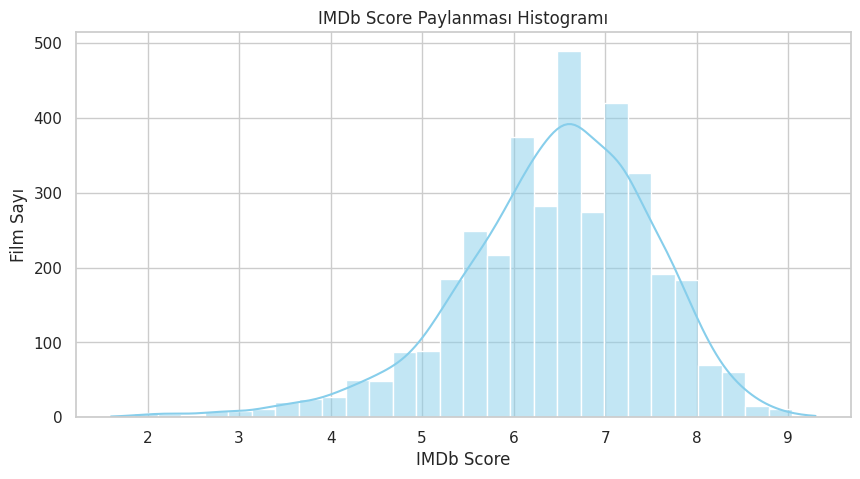

In [26]:
#Task 1:Filmlərin IMDb Score paylanmasını histogramla göstərin.
#Əlavə olaraq,normal paylanmaya yaxın olub-olmadığını müşahidə edin.

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['IMDb Score (1-10)'], kde=True, bins=30, color='skyblue')
plt.title('IMDb Score Paylanması Histogramı')
plt.xlabel('IMDb Score')
plt.ylabel('Film Sayı')
plt.show()

#Müşahidənin nəticəsi:Paylanma zəngvari formaya malikdir,lakin tam zəif sola meyllidir.
#Filmlərin böyük əksəriyyəti 6–7.5 aralığında təşkil edir.


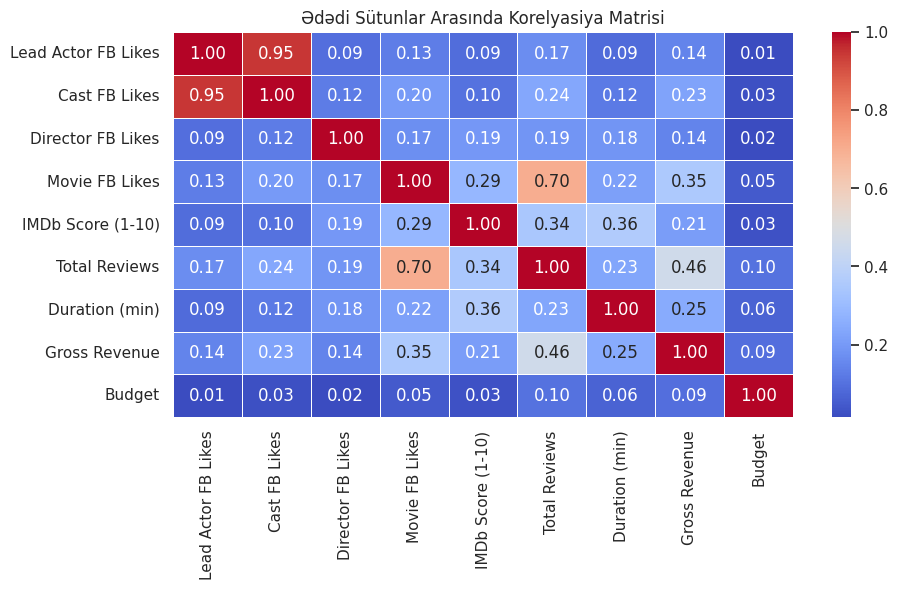

In [27]:
#Task 2:Datasetdəki ədədi sütunlar arasında korelyasiya matrisini hesablayın və heatmap ilə vizuallaşdırın.
#Ən güclü müsbət və mənfi əlaqələri müəyyən edin.

plt.figure(figsize=(10, 5))
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[numeric_columns].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Ədədi Sütunlar Arasında Korelyasiya Matrisi')
plt.show()

#Ən güclü müsbət əlaqə:Cast FB Likes ilə Lead Actor FB Likes(0.95)
#Baş rol aktyorunun bəyənməsi artdıqca aktyor heyətinin ümumi bəyənməsi də
#düz mütənasib artır.
#Ən zəif mənfiyə yaxın əlaqə:Budget ilə aktyor və rejissorların
#Facebook bəyənmələri arasında əlaqə demək olar ki,
#sıfıra yaxındır(təxminən 0.01 - 0.02).
#Deməli,yüksək büdcəli film çəkmək aktyorun sosial mediada populyar olması demək deyil.



/tmp/ipykernel_1017/3426691296.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genre', y='IMDb Score (1-10)', data=df_clean, palette='Set3')


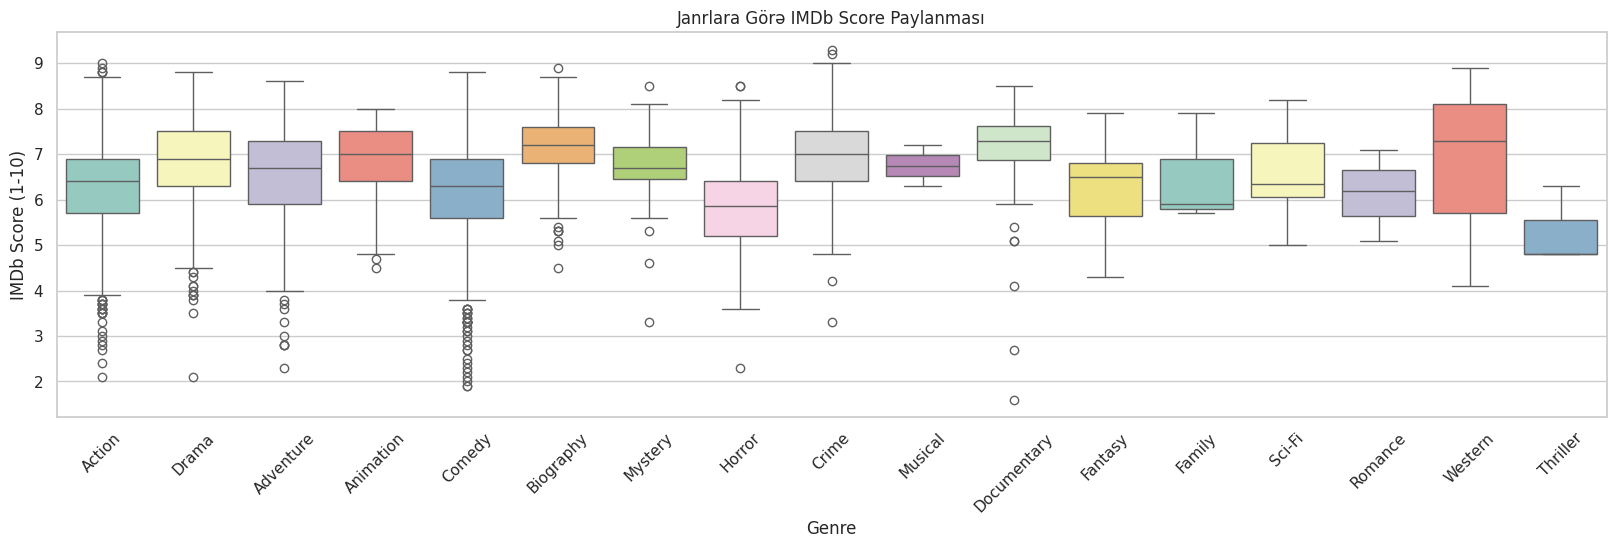

In [28]:
#Task 3:Filmlərin Genre-yə görə IMDb Score paylanmasını boxplot ilə göstərin.
#Hansı janr daha yüksək median bala malikdir?Kənara çıxmalar var mı?

plt.figure(figsize=(20, 5))
sns.boxplot(x='Genre', y='IMDb Score (1-10)', data=df_clean, palette='Set3')
plt.xticks(rotation=45)
plt.title('Janrlara Görə IMDb Score Paylanması')
plt.show()

#Yüksək Median Bala Malik Janrlar:Western,Documentary və Biography
#Kənara çıxmalar(Outliers):Bəli,xüsusən Drama,Comedy,Action janrlarında
#aşağı tərəfə doğru ciddi kənara çıxmalar(outliers) var(məsələn, IMDb balı 3-dən aşağı olan filmlər).

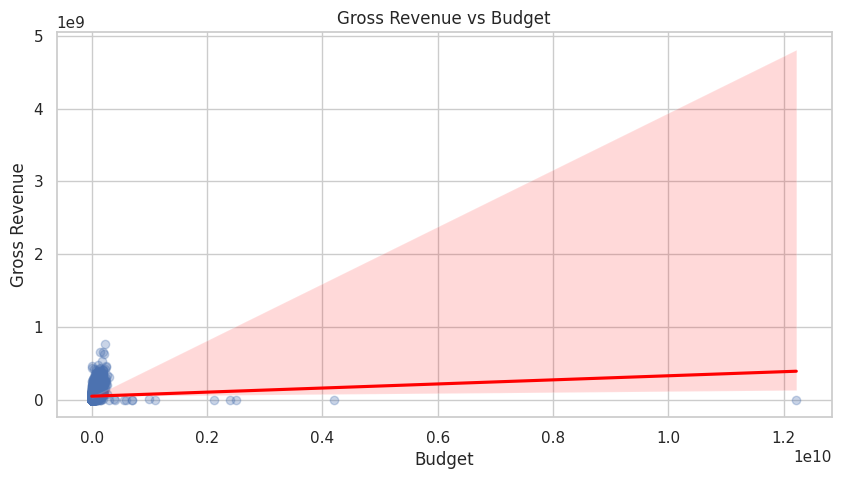

In [29]:
#Task 4:Gross Revenue ilə Budget arasındakı əlaqəni scatter plot və linear regression xətti ilə vizuallaşdırın.

plt.figure(figsize=(10, 5))
sns.regplot(x='Budget',y='Gross Revenue',data=df_clean,scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Gross Revenue vs Budget')
plt.xlabel('Budget')
plt.ylabel('Gross Revenue')
plt.show()

#Qrafikdən çıxan nəticə:Korelyasiya nisbətən aşağıdır.Regression xətti göstərir ki,büdcəsi çox olan filmlər
#hər zaman yüksək gəlir gətirmir.Lakin ən yüksək gəlir əldə edən
#filmlərin böyük hissəsi yüksək büdcəli olanlardır.

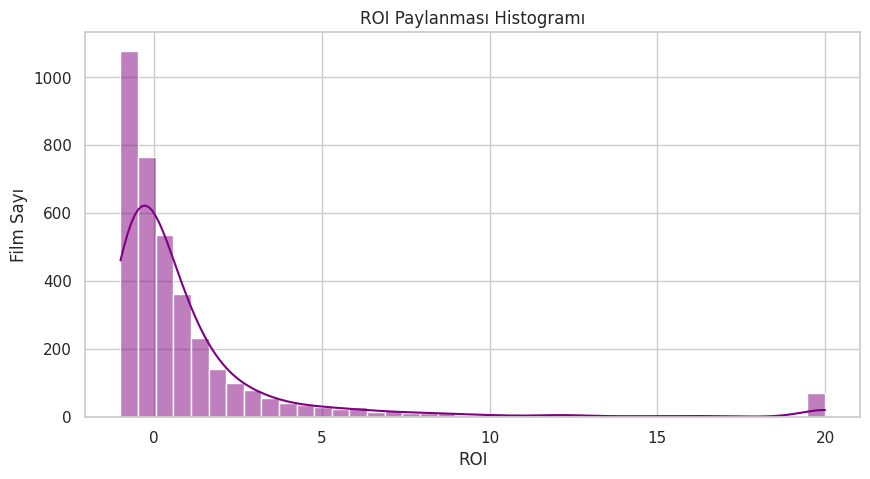

In [30]:
#Task 5:Yeni sütun yaradın:ROI(Return on Investment)=(Gross Revenue - Budget)/Budget.
#ROI-nin paylanmasını histogramla göstərin.

df_clean['ROI'] = (df_clean['Gross Revenue'] - df_clean['Budget']) / df_clean['Budget']
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['ROI'].clip(lower=-1, upper=20), bins=40, kde=True, color='purple')
plt.title('ROI Paylanması Histogramı')
plt.xlabel('ROI')
plt.ylabel('Film Sayı')
plt.show()

#Qrafikdən çıxan nəticə:Paylanma kəskin sağa meyllidir(right-skewed).
#Bəzi kiçik büdcəli qorxu filmləri(məsələn, Paranormal Activity kimi)
#minlərlə dəfə gəlir gətirərək böyük outlier-lər yaradır.

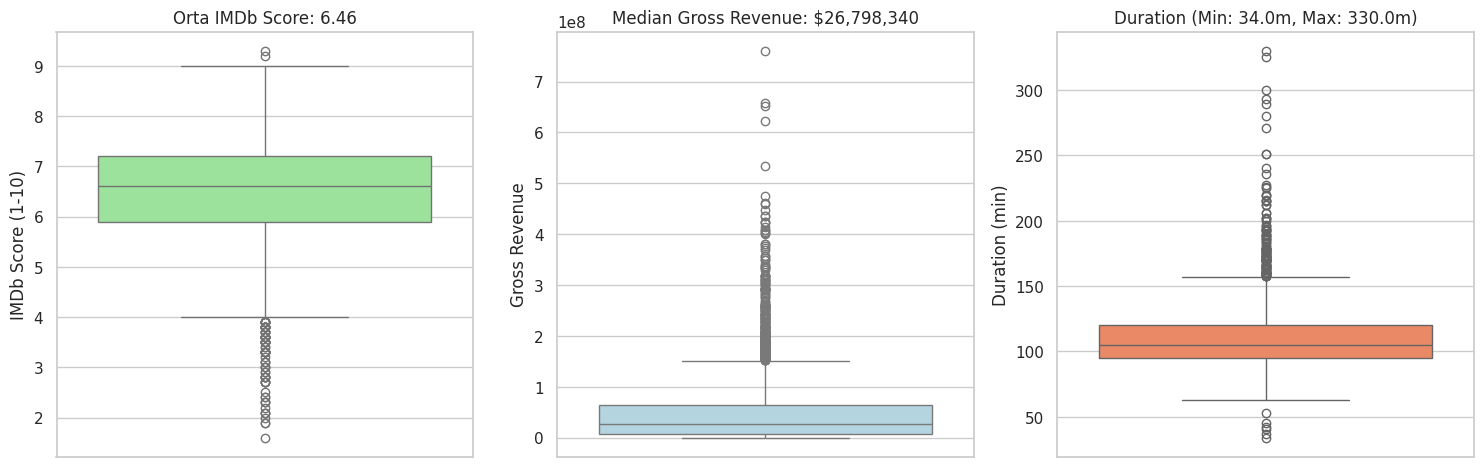

In [31]:
#Task 6:Dataset üzrə aşağıdakı statistikaları hesablayın:
# ●	Orta IMDb Score
# ●	Median Gross Revenue
# ●	Ən uzun və ən qısa Duration(min)
#Bu paylanmaları vizuallaşdırın.

mean_imdb = df_clean['IMDb Score (1-10)'].mean()
median_gross = df_clean['Gross Revenue'].median()
max_duration = df_clean['Duration (min)'].max()
min_duration = df_clean['Duration (min)'].min()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df_clean['IMDb Score (1-10)'], ax=axes[0], color='lightgreen')
axes[0].set_title(f'Orta IMDb Score: {mean_imdb:.2f}')
sns.boxplot(y=df_clean['Gross Revenue'], ax=axes[1], color='lightblue')
axes[1].set_title(f'Median Gross Revenue: ${median_gross:,.0f}')
sns.boxplot(y=df_clean['Duration (min)'], ax=axes[2], color='coral')
axes[2].set_title(f'Duration (Min: {min_duration}m, Max: {max_duration}m)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1017/4211917176.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Director Name', y='IMDb Score (1-10)', data=top5_directors_df, palette='viridis')


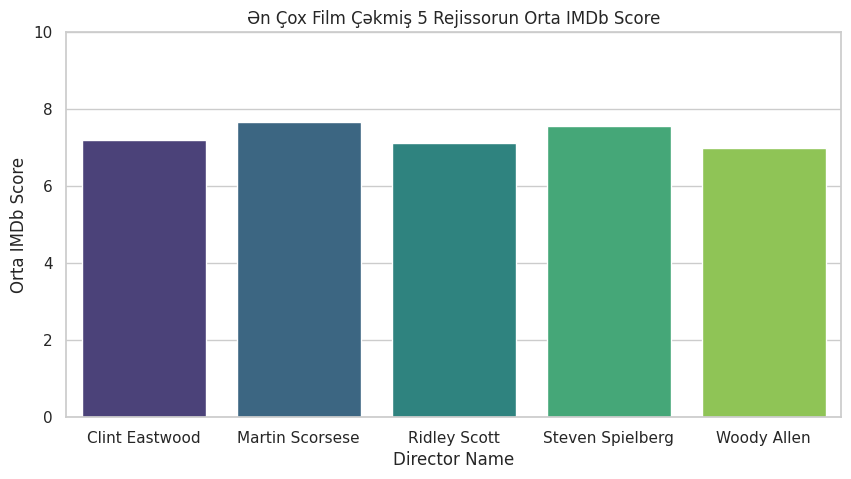

In [36]:
#Task 7:Ən çox film çəkmiş 5 rejissoru seçin və onların orta IMDb Score-larını barplot ilə göstərin.

top5_directors = df_clean['Director Name'].value_counts().head(5).index
top5_directors_df = df_clean[df_clean['Director Name'].isin
(top5_directors)].groupby('Director Name')['IMDb Score (1-10)'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Director Name', y='IMDb Score (1-10)', data=top5_directors_df, palette='viridis')
plt.title('Ən Çox Film Çəkmiş 5 Rejissorun Orta IMDb Score')
plt.ylabel('Orta IMDb Score')
plt.ylim(0, 10)
plt.show()




In [44]:
#Task 8:Genre-yə görə filmləri qruplaşdırın və hər janr üçün orta Budget və orta Gross Revenue hesablayın.

genre_statistics = df_clean.groupby('Genre')[['Budget', 'Gross Revenue']].mean().reset_index()
genre_statistics['Budget'] = genre_statistics['Budget'].round(0).astype(int)
genre_statistics['Gross Revenue'] = genre_statistics['Gross Revenue'].round(0).astype(int)
genre_statistics

,Genre,Budget,Gross Revenue
0,Action,70025078,75000373
1,Adventure,68660521,85275694
2,Animation,54905111,84681657
3,Biography,25429483,36722966
4,Comedy,35146814,37473689
5,Crime,41804054,32221060
6,Documentary,8600712,12460097
7,Drama,28623069,29754869
8,Family,14833333,149160478
9,Fantasy,16751429,39997006


/tmp/ipykernel_1017/2760760283.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gross Revenue', y='Title', data=top5_usa_gross, palette='magma')


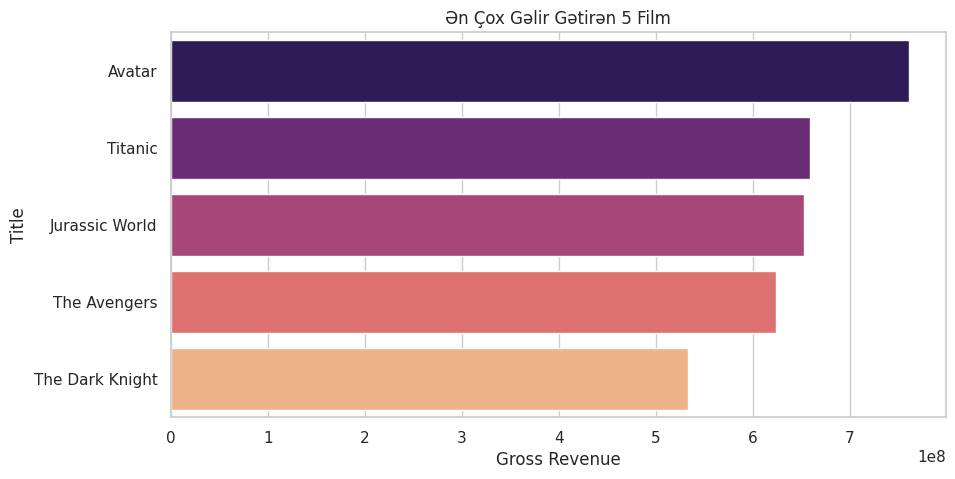

In [47]:
#Task 9:Language = English və Country = USA olan filmlər arasında ən çox gəlir gətirən
#5 filmi seçin və barplot ilə göstərin.

eng_usa = df_clean[(df_clean['Language'] == 'English') & (df_clean['Country'] == 'USA')]
top5_usa_gross = eng_usa.sort_values(by='Gross Revenue', ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(x='Gross Revenue', y='Title', data=top5_usa_gross, palette='magma')
plt.title('Ən Çox Gəlir Gətirən 5 Film')
plt.xlabel('Gross Revenue')
plt.show()

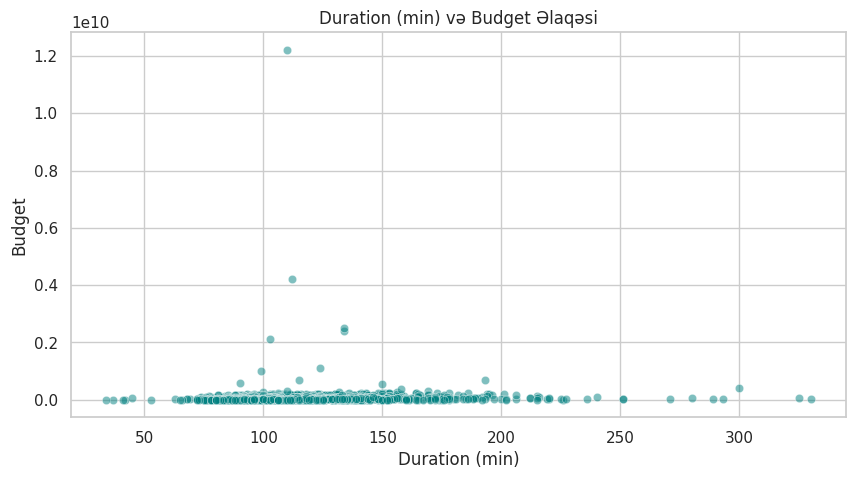

In [61]:
#Task 10:Filmin müddəti ilə büdcəsi arasındakı əlaqəni vizuallaşdırıb şərh edin.

plt.figure(figsize=(10, 5))
sns.scatterplot(x='Duration (min)', y='Budget', data=df_clean, alpha=0.5, color='teal')
plt.title('Duration (min) və Budget Əlaqəsi')
plt.xlabel('Duration (min)')
plt.ylabel('Budget')
plt.show()

#Şərh:Filmin müddətinin uzun olması onun büdcəsinin mütləq böyük olacağı mənasına gəlmir.